# Import Libaries

In [13]:
import kagglehub
import pandas as pd
import random
import cv2
import matplotlib.pyplot as plt

from pathlib import Path

# 0. Load Data

In [5]:
path = kagglehub.dataset_download(
    "abdallahwagih/ucf101-videos",
    output_dir="data"
)

DATA_PATH = Path(path)

print(DATA_PATH)

data


# 1. Data Inspection

## Inspect Downloaded Folder and Files

In [6]:
print(list(DATA_PATH.iterdir()))

[WindowsPath('data/.complete'), WindowsPath('data/test'), WindowsPath('data/test.csv'), WindowsPath('data/train'), WindowsPath('data/train.csv')]


In [15]:
print("Train:")
print(list((DATA_PATH / "train").iterdir())[:5])

print("\nTest:")
print(list((DATA_PATH / "test").iterdir())[:5])

Train:
[WindowsPath('data/train/v_CricketShot_g08_c01.avi'), WindowsPath('data/train/v_CricketShot_g08_c02.avi'), WindowsPath('data/train/v_CricketShot_g08_c03.avi'), WindowsPath('data/train/v_CricketShot_g08_c04.avi'), WindowsPath('data/train/v_CricketShot_g08_c05.avi')]

Test:
[WindowsPath('data/test/v_CricketShot_g01_c01.avi'), WindowsPath('data/test/v_CricketShot_g01_c02.avi'), WindowsPath('data/test/v_CricketShot_g01_c03.avi'), WindowsPath('data/test/v_CricketShot_g01_c04.avi'), WindowsPath('data/test/v_CricketShot_g01_c05.avi')]


In [8]:
train_df = pd.read_csv(DATA_PATH / "train.csv")
test_df = pd.read_csv(DATA_PATH / "test.csv")

print(train_df.head())

print(test_df.head())

                  video_name          tag
0  v_CricketShot_g08_c01.avi  CricketShot
1  v_CricketShot_g08_c02.avi  CricketShot
2  v_CricketShot_g08_c03.avi  CricketShot
3  v_CricketShot_g08_c04.avi  CricketShot
4  v_CricketShot_g08_c05.avi  CricketShot
                  video_name          tag
0  v_CricketShot_g01_c01.avi  CricketShot
1  v_CricketShot_g01_c02.avi  CricketShot
2  v_CricketShot_g01_c03.avi  CricketShot
3  v_CricketShot_g01_c04.avi  CricketShot
4  v_CricketShot_g01_c05.avi  CricketShot


### Info
The dataset already contains prepared **train** and **test** sets, together with `train.csv` and `test.csv`.
- The **video folders** contain the actual video files that will be loaded and processed by our model.
- The **CSV files** contain information that tells us which video belongs to which class (label). We will use them to connect each video with its correct target label during training and evaluation.

## Basic Data Inspection

In [9]:
print("="*50)
print("DATA INSPECTION")
print("="*50)

print("\nShapes:")
print("Train: ", train_df.shape)
print("Test: ", test_df.shape)

print("\nNull Values:")
print("Train: ", train_df.isnull().sum())
print("\nTest: ", test_df.isnull().sum())

print("\nNumber of classes: ")
print('Classes: ', len(train_df["tag"].unique()))
print(list(train_df["tag"].unique()))

print("\nClass distibution:")
print("Train: ", train_df["tag"].value_counts())
print("\nTest: ", test_df["tag"].value_counts())

DATA INSPECTION

Shapes:
Train:  (594, 2)
Test:  (224, 2)

Null Values:
Train:  video_name    0
tag           0
dtype: int64

Test:  video_name    0
tag           0
dtype: int64

Number of classes: 
Classes:  5
['CricketShot', 'PlayingCello', 'Punch', 'ShavingBeard', 'TennisSwing']

Class distibution:
Train:  tag
Punch           121
PlayingCello    120
CricketShot     118
ShavingBeard    118
TennisSwing     117
Name: count, dtype: int64

Test:  tag
CricketShot     49
TennisSwing     49
PlayingCello    44
ShavingBeard    43
Punch           39
Name: count, dtype: int64


### Info
The dataset consists of **818 observations**: **594 for training** and **224 for testing**. There are **no missing values** in either the training or test dataset. The dataset contains **5 classes**, which are **evenly distributed** across both the training and test sets.

## Display First Frame of Random Video

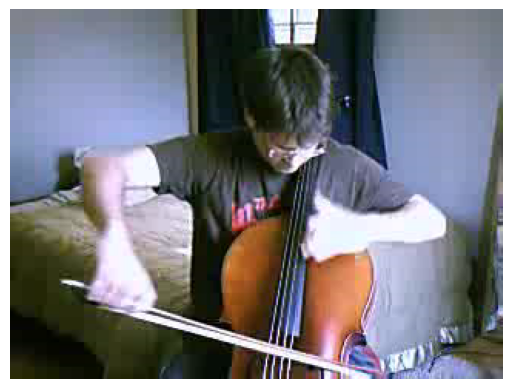

In [14]:
video_paths = list((DATA_PATH / "train").rglob("*.avi"))

video_path = random.choice(video_paths)

cap = cv2.VideoCapture(str(video_path))

ret, frame = cap.read()

if ret:
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame)
    plt.axis("off")
    plt.show()

cap.release()

# 2. Evaluate Data Analysis

In [16]:
video_info = []

for video_path in video_paths:

    cap = cv2.VideoCapture(str(video_path))

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame_count / fps if fps > 0 else 0

    video_info.append({
        "video": video_path.name,
        "fps": fps,
        "frames": frame_count,
        "width": width,
        "height": height,
        "duration": duration
    })

    # Free up resources
    cap.release()


video_info_df = pd.DataFrame(video_info)

video_info_df.head()

,video,fps,frames,width,height,duration
0,v_CricketShot_g08_c01.avi,25.0,75,320,240,3.00
1,v_CricketShot_g08_c02.avi,25.0,75,320,240,3.00
2,v_CricketShot_g08_c03.avi,25.0,53,320,240,2.12
3,v_CricketShot_g08_c04.avi,25.0,68,320,240,2.72
4,v_CricketShot_g08_c05.avi,25.0,98,320,240,3.92


In [17]:
video_info_df.describe()

,fps,frames,width,height,duration
count,594.000000,594.000000,594.0,594.0,594.000000
mean,25.978945,200.695286,320.0,240.0,7.804110
std,1.978293,83.992550,0.0,0.0,3.393927
min,25.000000,46.000000,320.0,240.0,1.840000
25%,25.000000,124.250000,320.0,240.0,4.490000
50%,25.000000,205.000000,320.0,240.0,8.080000
75%,25.000000,281.750000,320.0,240.0,11.000000
max,29.970030,388.000000,320.0,240.0,15.520000


### EDA Observations
* All videos have the same resolution of **320 × 240 pixels**.
* The videos have an average of approximately **26 FPS**, with most videos using **25 FPS**.
* The average video contains approximately **201 frames**, with values ranging from **46 to 388 frames**.
* The average video duration is approximately **7.8 seconds**, with videos ranging from **1.84 to 15.52 seconds**.
* The number of frames and video duration vary considerably between samples, which should be considered when preparing the videos for the model.